In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [19]:
# Load the diabetes dataset
diabetes_data = load_diabetes()
print(diabetes_data.keys())

diabetes_df = pd.DataFrame(data=diabetes_data.data, columns=diabetes_data.feature_names)
diabetes_df.head()

dict_keys(['data', 'target', 'frame', 'DESCR', 'feature_names', 'data_filename', 'target_filename', 'data_module'])


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [20]:
y = pd.Series(diabetes_data.target, name='target')
y.head()


0    151.0
1     75.0
2    141.0
3    206.0
4    135.0
Name: target, dtype: float64

In [21]:
X_train, X_test, y_train, y_test = train_test_split(diabetes_df, y, test_size=0.2, random_state=42)

print(f"X train shape, y train shape: {X_train.shape[0]} samples, {y_train.shape[0]} samples")
print(f"X test shape, y test shape: {X_test.shape[0]} samples, {y_test.shape[0]} samples")


X train shape, y train shape: 353 samples, 353 samples
X test shape, y test shape: 89 samples, 89 samples


In [36]:
# Create a linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)


# Print model coefficients and intercept
coef_pd = pd.DataFrame({
    "Feature": diabetes_df.columns, 
    "Coefficient": model.coef_}).sort_values(by="Coefficient", ascending=False) 
print(coef_pd)

print(f"Model intercept: {model.intercept_}")   


  Feature  Coefficient
8      s5   736.198859
2     bmi   542.428759
5      s2   518.062277
3      bp   347.703844
7      s4   275.317902
6      s3   163.419983
9      s6    48.670657
0     age    37.904021
1     sex  -241.964362
4      s1  -931.488846
Model intercept: 151.34560453985995


In [39]:
# Evaluate the model
residuals = y_test - y_pred

r2_score_train = model.score(X_train, y_train)
print(f"R-squared score (train): {r2_score_train:.4f}")
r2_score_test = model.score(X_test, y_test)
print(f"R-squared score (test): {r2_score_test:.4f}")

mae_test = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error (test): {mae_test:.4f}")
mse_test = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error (test): {mse_test:.4f}")
rmse_test = np.sqrt(mse_test)
print(f"Root Mean Squared Error (test): {rmse_test:.4f}")


R-squared score (train): 0.5279
R-squared score (test): 0.4526
Mean Absolute Error (test): 42.7941
Mean Squared Error (test): 2900.1936
Root Mean Squared Error (test): 53.8534


Text(0, 0.5, 'Predicted Values')

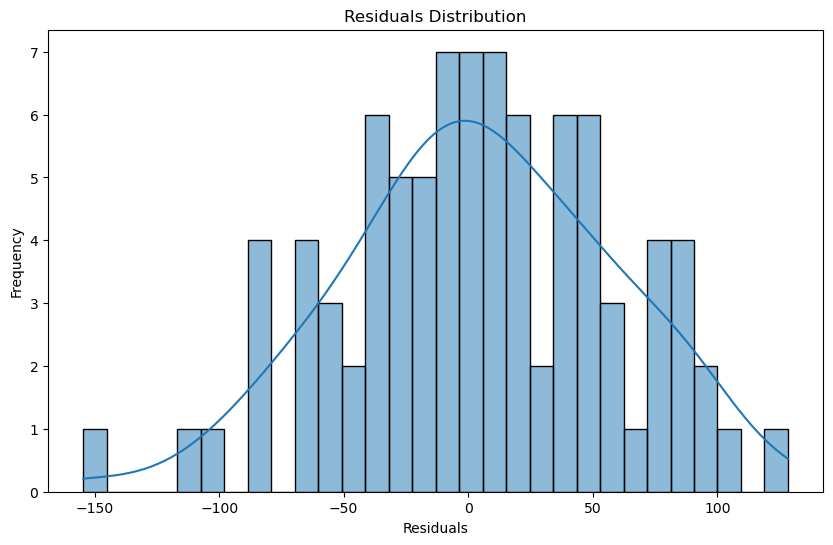

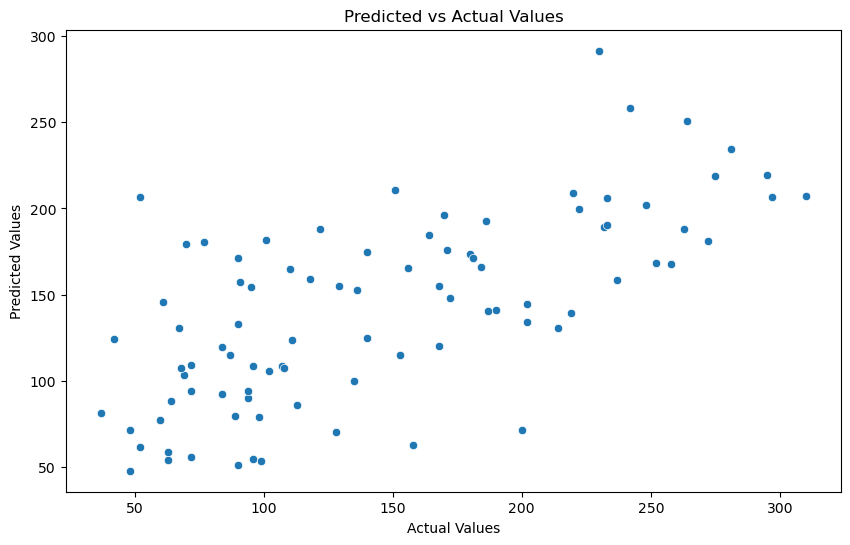

In [40]:
# Plot residuals
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, bins=30)
plt.title("Residuals Distribution")
plt.xlabel("Residuals")
plt.ylabel("Frequency") 

#Plot predicted vs actual values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.title("Predicted vs Actual Values")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")  